In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
# Add noise (forward diffusion)
def add_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)
    return noisy_image

# Denoise (reverse diffusion approximation)
def denoise_image(image):
    image = (image * 255).astype(np.uint8)
    denoised = cv2.GaussianBlur(image, (5,5), 0)
    denoised = denoised / 255.0
    return denoised

In [3]:
data = []
labels = []

dataset_path = "dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
classes = ["Normal","Cyst","Tumor","Stone"]

for label in classes:
    folder = os.path.join(dataset_path, label)
    
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        
        image = cv2.imread(img_path)
        image = cv2.resize(image, (128,128))
        image = image / 255.0
        
        # 🔥 Apply diffusion-style processing
        noisy = add_noise(image)
        denoised = denoise_image(noisy)
        
        # original image
        data.append(image)
        labels.append(classes.index(label))
        
        # augmented (diffusion)
        data.append(denoised)
        labels.append(classes.index(label))

data = np.array(data)
labels = np.array(labels)

print("Dataset shape after augmentation:", data.shape)

Dataset shape after augmentation: (24892, 128, 128, 3)


In [4]:
labels = to_categorical(labels, 4)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

In [6]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 191s 300ms/step - accuracy: 0.9005 - loss: 0.2602 - val_accuracy: 0.9990 - val_loss: 0.0051
Epoch 2/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.9907 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 5.3725e-04
Epoch 3/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.9942 - loss: 0.0172 - val_accuracy: 0.9992 - val_loss: 0.0040
Epoch 4/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 126s 203ms/step - accuracy: 0.9951 - loss: 0.0173 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 5/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 124s 199ms/step - accuracy: 0.9960 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 2.2843e-05
Epoch 6/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.9959 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 1.0095e-04
Epoch 7/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 125s 201ms/step - accuracy: 0.9968 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 3.4451e-04
Epoch 8/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 121s 195ms/step - ac

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 1.0000 - loss: 2.9539e-06
Test Accuracy: 1.0


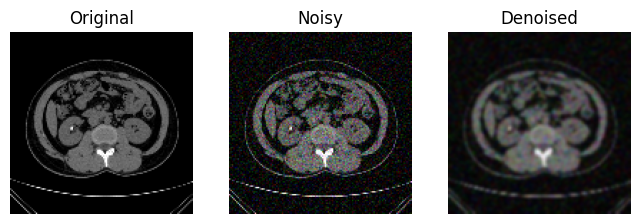

In [9]:
plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(denoised)
plt.title("Denoised")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


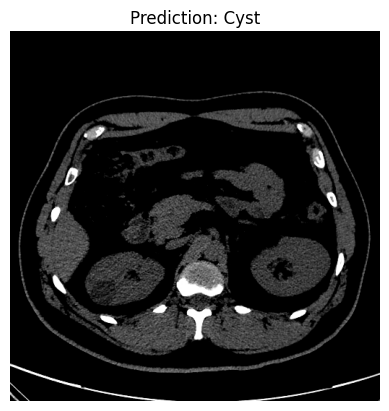

In [10]:
img = cv2.imread("test.jpg")
img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img,(128,128))
img = img/255.0
img = np.reshape(img,(1,128,128,3))

prediction = model.predict(img)

classes = ["Normal","Cyst","Tumor","Stone"]
result = classes[np.argmax(prediction)]

plt.imshow(img_display)
plt.title("Prediction: " + result)
plt.axis("off")
plt.show()

In [11]:
model.save("kidney_diffusion_cnn.keras")

In [1]:
from tensorflow.keras.models import load_model

model = load_model("kidney_diffusion_cnn.keras")

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

classes = ["Normal","Cyst","Tumor","Stone"]

In [3]:
def show_predictions_per_class(class_name, num_images=15):
    
    folder = os.path.join(dataset_path, class_name)
    images = os.listdir(folder)[:num_images]
    
    plt.figure(figsize=(15,10))
    
    for i, img_name in enumerate(images):
        
        img_path = os.path.join(folder, img_name)
        
        img = cv2.imread(img_path)
        img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        img_resized = cv2.resize(img,(128,128))
        img_resized = img_resized / 255.0
        img_resized = np.reshape(img_resized,(1,128,128,3))
        
        prediction = model.predict(img_resized, verbose=0)
        predicted_class = classes[np.argmax(prediction)]
        
        plt.subplot(3,5,i+1)
        plt.imshow(img_display)
        plt.title(f"P: {predicted_class}")
        plt.axis("off")
    
    plt.suptitle(f"{class_name} Class Predictions", fontsize=16)
    plt.show()

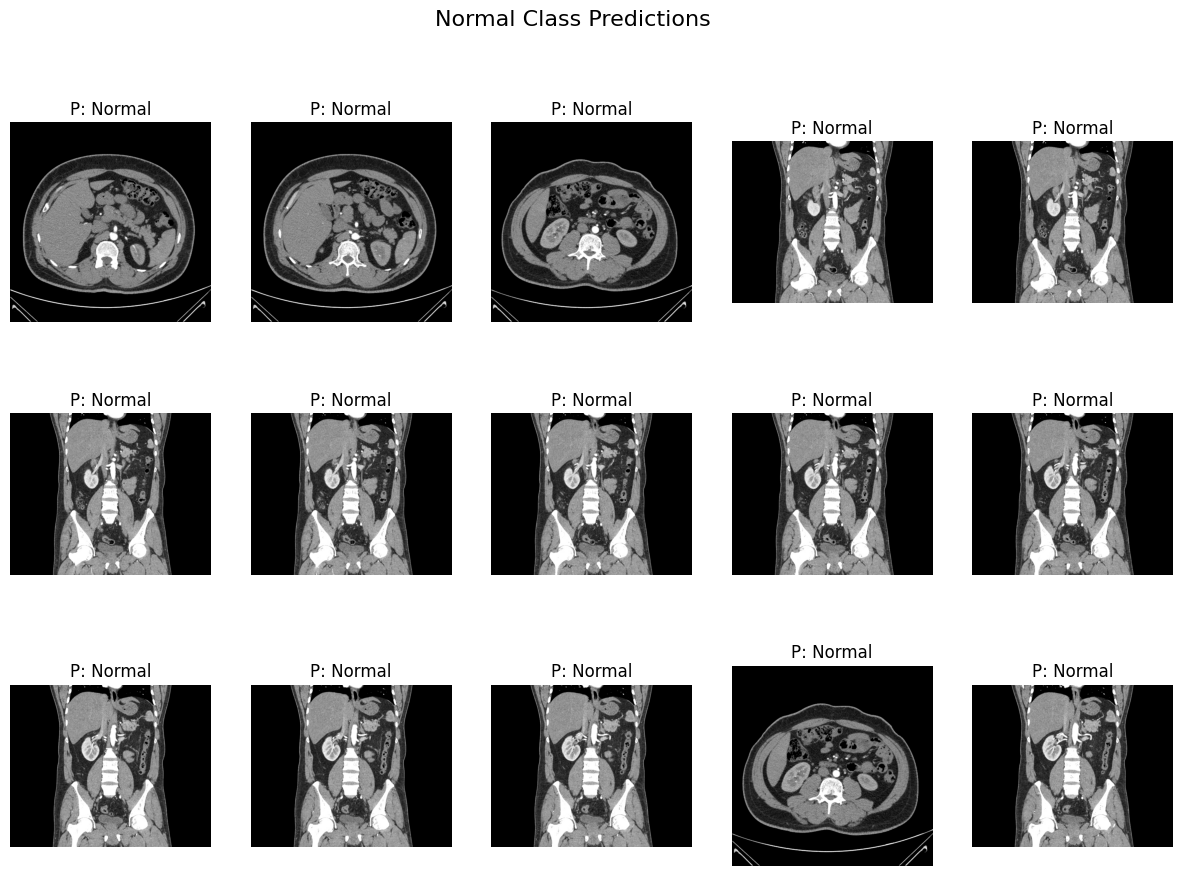

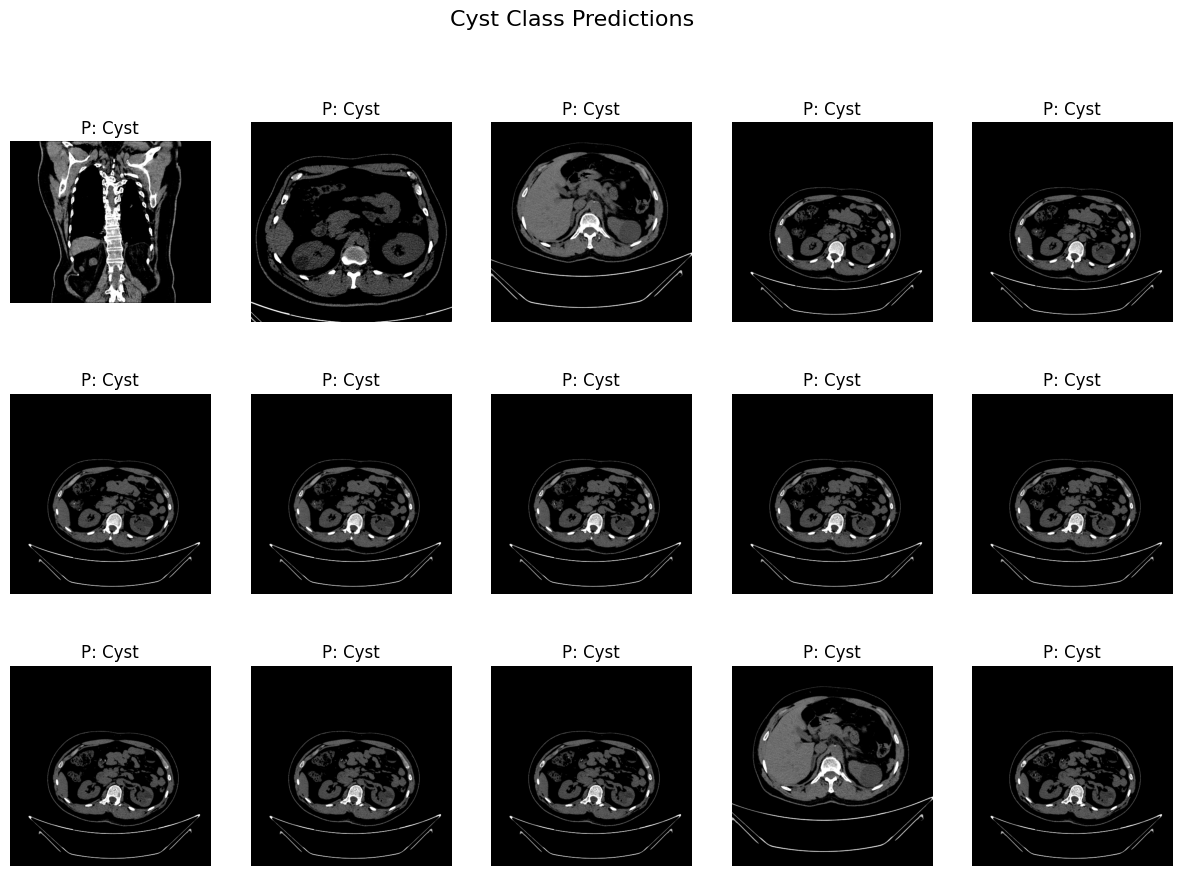

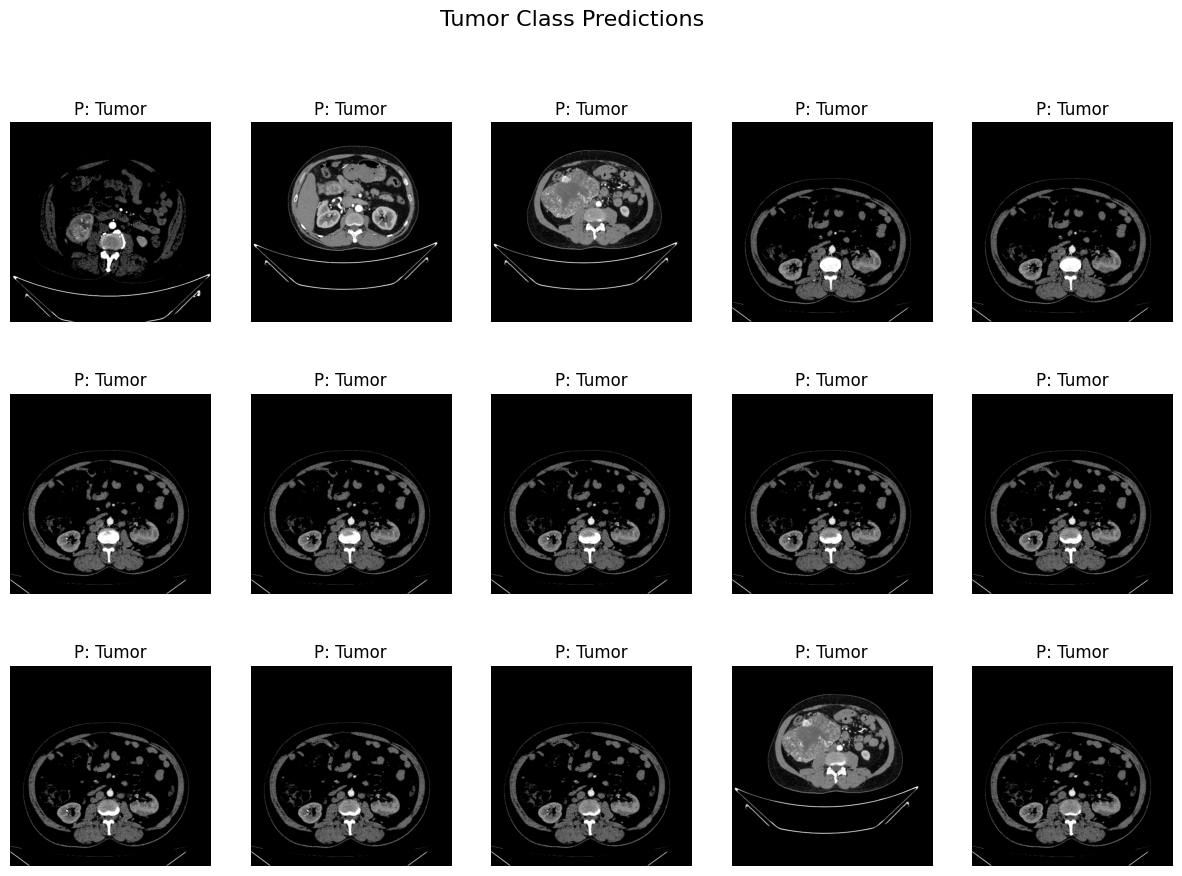

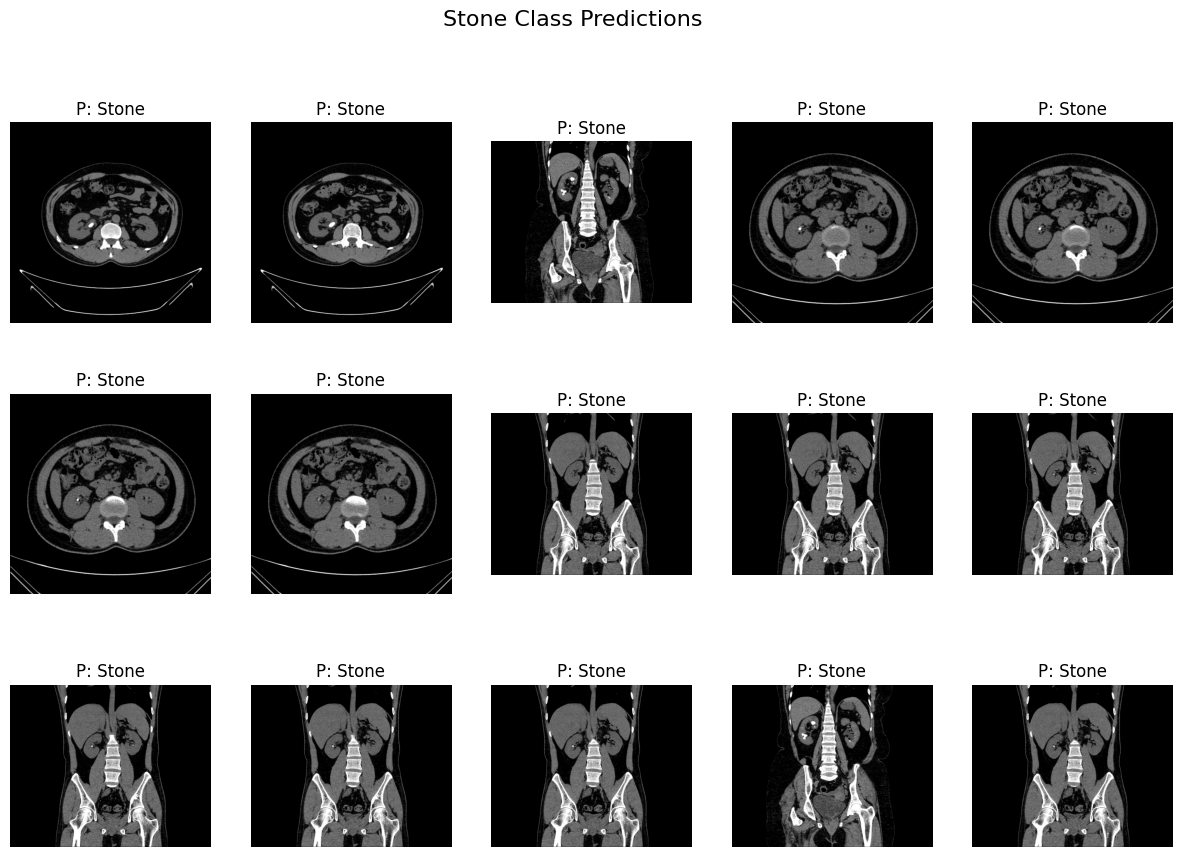

In [4]:
for cls in classes:
    show_predictions_per_class(cls, 15)